Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 129ms/step - accuracy: 0.3926 - loss: 1.6516 - val_accuracy: 0.5186 - val_loss: 1.3135
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.5159 - loss: 1.3454 - val_accuracy: 0.5755 - val_loss: 1.1838
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.5630 - loss: 1.2219 - val_accuracy: 0.6049 - val_loss: 1.1137
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 127ms/step - accuracy: 0.5958 - loss: 1.1355 - val_accuracy: 0.6405 - val_loss: 1.0330
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step - accuracy: 0.6194 - loss: 1.0733 - val_accuracy: 0.6757 - val_loss: 0.9135
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.6400 - loss: 1.0226 - val_accuracy: 0.6649 - val_loss: 0.9711
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.6548 - loss: 0.9816 - val_accuracy: 0.6660 - val_loss: 0.9777
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.6649 - los

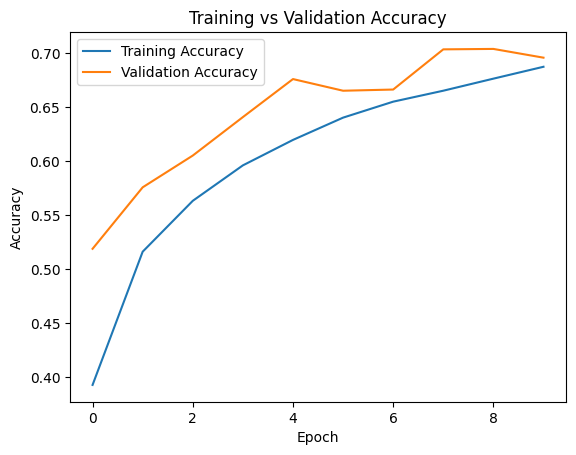

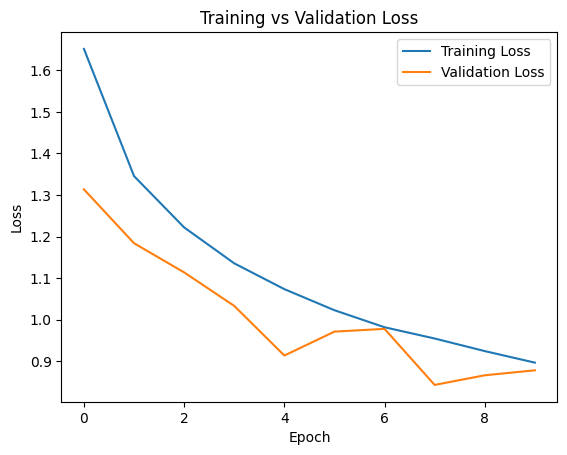

In [13]:
# ============================================================
# CNN Image Classification on CIFAR-10 with Data Augmentation
# ============================================================

# Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ============================================================
# 1. Load CIFAR-10 Dataset
# ============================================================

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# ============================================================
# 2. Normalize Images
# ============================================================

# Convert pixel values from 0–255 to 0–1
x_train = x_train / 255.0
x_test = x_test / 255.0

# ============================================================
# 3. Data Augmentation
# ============================================================

# Data augmentation artificially increases dataset size
# by creating modified versions of images

datagen = ImageDataGenerator(

    rotation_range=15,          # randomly rotate images up to 15 degrees
    width_shift_range=0.1,      # shift image horizontally
    height_shift_range=0.1,     # shift image vertically
    horizontal_flip=True,       # randomly flip images
    zoom_range=0.1              # random zoom
)

# Compute statistics required for augmentation
datagen.fit(x_train)

# ============================================================
# 4. Build CNN Model
# ============================================================

model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(layers.Conv2D(64,(3,3),activation='relu'))

# Flatten feature maps
model.add(layers.Flatten())

# Dense layer
model.add(layers.Dense(128,activation='relu'))

# Output layer
model.add(layers.Dense(10,activation='softmax'))

# ============================================================
# 5. Compile Model
# ============================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

# ============================================================
# 6. Train Model with Augmented Data
# ============================================================

history = model.fit(

    datagen.flow(x_train, y_train, batch_size=64),   # augmented images
    epochs=10,
    validation_data=(x_test, y_test)
)

# ============================================================
# 7. Evaluate Model
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

# ============================================================
# 8. Plot Accuracy Graph
# ============================================================

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.show()

# ============================================================
# 9. Plot Loss Graph
# ============================================================

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()